## EMPLOYEE BURNOUT PREDICTION USING MACHINE LEARNING

## PROBLEM STATEMENT
Employee burnout is a state of physical and emotional exhaustion caused by prolonged work-related stress. Identifying employees at risk of burnout can help organizations take proactive measures to improve employee well-being, productivity, and work-life balance. The aim of this project is to build a machine learning model that predicts whether an employee is at high risk of burnout using work-related and psychological factors.

## IMPORT LIBRARIES

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## LOAD DATASET

In [34]:
df = pd.read_csv(r"C:\Users\aayus\Downloads\archive (10)\train.csv")

In [35]:
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


## DATASET DESCRIPTION


In [36]:
df.shape

(22750, 9)

In [37]:
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [39]:
df.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [40]:
df.nunique()

Employee ID             22750
Date of Joining           366
Gender                      2
Company Type                2
WFH Setup Available         2
Designation                 6
Resource Allocation        10
Mental Fatigue Score      101
Burn Rate                 101
dtype: int64

In [41]:
df.isnull().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

In [42]:
df.duplicated().sum()

np.int64(0)

## EXPLORATORY DATA ANALYSIS(EDA)


## BURN RATE DISTRIBUTION

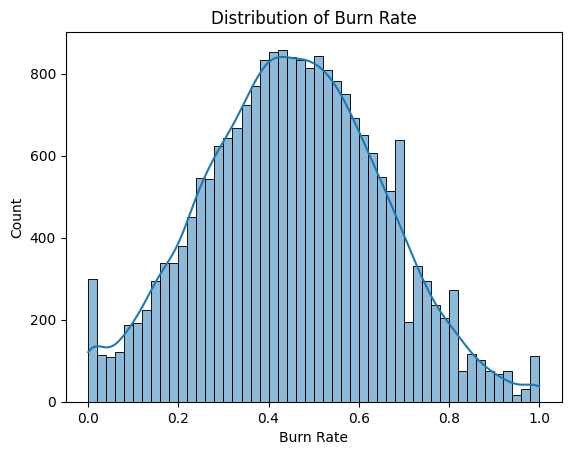

In [44]:
sns.histplot(df['Burn Rate'], kde=True)
plt.title('Distribution of Burn Rate')
plt.show()

## GENDER VS BURN RATE

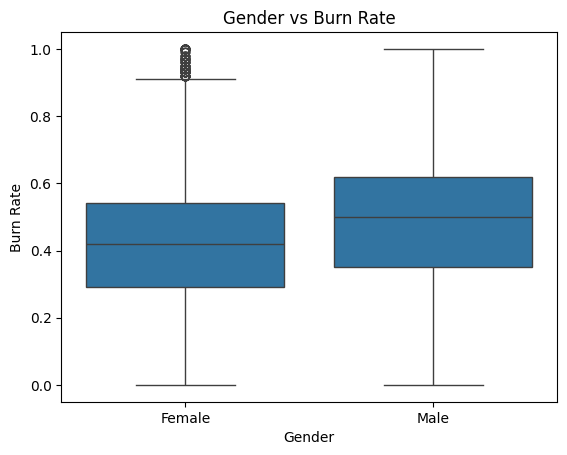

In [45]:
sns.boxplot(x='Gender', y='Burn Rate', data=df)
plt.title('Gender vs Burn Rate')
plt.show()

## COMPANY TYPE VS BURN RATE

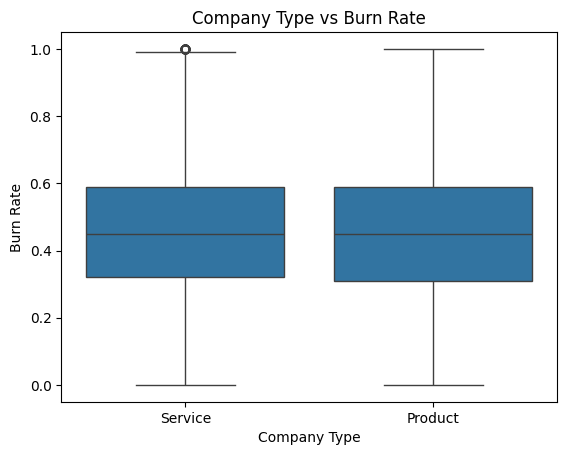

In [46]:
sns.boxplot(x='Company Type', y='Burn Rate', data=df)
plt.title('Company Type vs Burn Rate')
plt.show()

## MENTAL FATIGUE SCORE VS BURN RATE

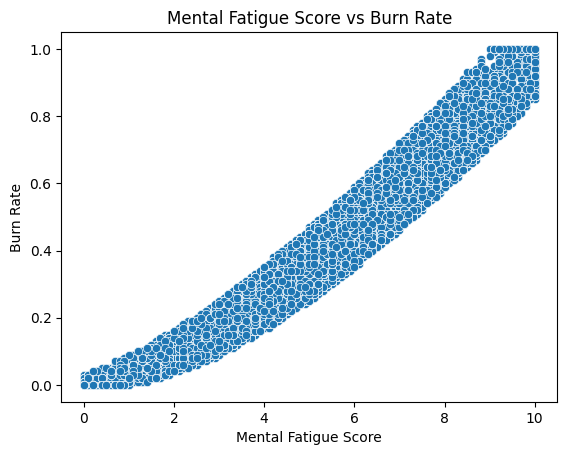

In [47]:
sns.scatterplot(x='Mental Fatigue Score', y='Burn Rate', data=df)
plt.title('Mental Fatigue Score vs Burn Rate')
plt.show()

## DATA PREPROCESSING

## DROPPING UNNECESSARY COLUMNS

In [48]:
df = df.drop(['Employee ID', 'Date of Joining'], axis=1)

## HANDLING MISSING VALUES

In [49]:
df['Resource Allocation'] = df['Resource Allocation'].fillna(
    df['Resource Allocation'].median()
)

df['Mental Fatigue Score'] = df['Mental Fatigue Score'].fillna(
    df['Mental Fatigue Score'].median()
)

df['Burn Rate'] = df['Burn Rate'].fillna(
    df['Burn Rate'].median()
)

## CREATING TARGET VARIABLE

In [50]:
df['Burnout_Risk'] = df['Burn Rate'].apply(
    lambda x: 1 if x > 0.5 else 0
)

In [51]:
df.drop('Burn Rate', axis=1, inplace=True)

## ENCODING CATEGORICAL VARIABLES

In [52]:
le_gender = LabelEncoder()
le_company = LabelEncoder()
le_wfh = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])

df['Company Type'] = le_company.fit_transform(df['Company Type'])

df['WFH Setup Available'] = le_wfh.fit_transform(
    df['WFH Setup Available']
)

## DEFINING FEATURES AND TARGET VARIABLE

In [53]:
X = df.drop('Burnout_Risk', axis=1)

y = df['Burnout_Risk']

## TRAIN-TEST SPLIT

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## FEATURE SCALING

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## MODEL BUILDING

## Logistic Regression

In [56]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

Logistic Regression Accuracy: 0.914945054945055


## Random Forest Classifier

In [57]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Random Forest Accuracy: 0.9096703296703297


## MODEL EVALUATION

In [58]:
print(confusion_matrix(y_test, y_pred_rf))

[[2626  204]
 [ 207 1513]]


In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2830
           1       0.88      0.88      0.88      1720

    accuracy                           0.91      4550
   macro avg       0.90      0.90      0.90      4550
weighted avg       0.91      0.91      0.91      4550



## MODEL COMPARISON

In [60]:
print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Logistic Regression Accuracy: 0.914945054945055
Random Forest Accuracy: 0.9096703296703297


## RESULT AND CONCLUSION
Among the models evaluated, Logistic Regression achieved the highest accuracy of 91.49% in predicting employee burnout risk. The developed model can help organizations proactively identify employees at risk of burnout and implement strategies to improve employee well-being, productivity, and work-life balance. Early identification of burnout risk can support timely interventions and contribute to a healthier and more productive workforce.